In [3]:
import nilearn
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op
from brainspace.utils.parcellation import map_to_labels

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'

base_folder = op.join(bids_folder, 'derivatives' ,'dwi_connectome')
plot_folder = op.join(bids_folder, 'plots_and_ims', 'DTI')

subList = [f'{i:02d}' for i in range(1, 67)]
sub_array= np.array([int(i) for i in subList]) 

### Individual sCM& fCM

In [ ]:
# structural
atlas = 'Glasser_hemiUnique' #'AAL3_amended' # 
sub = subList[0]

connectome_file = op.join(base_folder, f'sub-{sub}', 'processing', 'connectome', atlas , 'connectome.csv')
connectome = pd.read_csv(connectome_file,header=None)
mu_factor = pd.read_table(op.join(base_folder,f'sub-{sub}', 'processing', 'tractography/two_tissue/SIFT2_mu.txt'),header=None).values[0][0]
C = np.array(connectome)
cm_s = (C + C.T) * mu_factor

from utils import resample_to_gaussian
cm_s_gaussian = resample_to_gaussian(cm_s, mean=1, std=0.5)


In [ ]:
# Remoce unconnected nodes (disturbeds GM fitting)
CM = cm_s_gaussian
# Check for rows/columns of zeros
zero_rows = np.all(CM == 0, axis=1)
zero_cols = np.all(CM == 0, axis=0)

valid_mask = ~(zero_rows | zero_cols) 
CM_clean = CM[valid_mask][:, valid_mask]
parcels_mask = valid_mask

In [ ]:
# functional 
source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices.parcel')
confspec = '32Pscrub3BPfilter'
cm_file = op.join(source_folder,f'sub-{sub}_glasserParcel-fsaverage_confspec-{confspec}.npy')
cm_f = np.load(cm_file)

# only top 10 connections
top_n = int(360/10)
cm_f_top10 = np.zeros_like(cm_f)
for ii,row in enumerate(cm_f): 
    top_10_ind = np.argsort(row)[-top_n:][::-1] # argsort returns indices of sorted array in ascending order, [-top_n:] takees therefore the top (here=last) 36, [::-1] reverses the array
    cm_f_top10[ii, top_10_ind] = row[top_10_ind]



### Average sCM 
distance-dependent group consensus structural connectivity graph.

In [ ]:
# apply to averge connectome
import nibabel as nib
atlas_nii = nib.load(op.join('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk', 
            'GlasserParcellationAtlas_MNI_hemiUnique/HCP-MMP1_on_MNI152_ICBM2009a_nlin_hemi-unique.nii.gz'))

from utils import get_parcel_infos
coords, distances = get_parcel_infos(atlas_nii.get_fdata(), atlas_nii.affine )

print(len(coords), coords.shape, distances.shape)

In [17]:
atlas = 'Glasser_hemiUnique' #
cmSs = []
for sub in subList:
    connectome_file = op.join(base_folder, f'sub-{sub}', 'processing', 'connectome', atlas , 'connectome.csv')
    connectome = pd.read_csv(connectome_file,header=None)
    mu_factor = pd.read_table(op.join(base_folder,f'sub-{sub}', 'processing', 'tractography/two_tissue/SIFT2_mu.txt'),header=None).values[0][0]
    C = np.array(connectome)
    cm_s = (C + C.T) * mu_factor
    cmSs.append(cm_s)        #(cm_s - np.mean(cm_s)) / np.std(cm_s))

cmSs = np.array(cmSs)
cmSs_reshaped = cmSs.transpose(1, 2, 0)


In [29]:
#  Calculate distance-dependent group consensus structural connectivity graph.
# netneurotools.networks.struct_consensus(data, distance, hemiid, conn_num_inter=None, conn_num_intra=None, weighted=False)[source]
from netneurotools.networks import struct_consensus

hemiid = np.array([0 if i < (360/2) else 1 for i in range(360)]).reshape(-1, 1)
cons_meanCM = struct_consensus(cmSs_reshaped, distances, hemiid, weighted=True)


### Plot CMs & their edge distributions

(array([5.22687547e+00, 4.59315238e-02, 2.37491542e-02, 1.31939745e-02,
        9.73055622e-03, 7.00929897e-03, 4.78281577e-03, 3.95819236e-03,
        2.47387022e-03, 1.48432213e-03, 9.07085749e-04, 9.89548090e-04,
        1.64924682e-04, 1.64924682e-04, 4.94774045e-04, 3.29849363e-04,
        1.64924682e-04, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.64924682e-04, 8.24623408e-05, 0.00000000e+00,
        1.64924682e-04, 0.00000000e+00, 2.47387022e-04, 0.00000000e+00,
        0.00000000e+00, 8.24623408e-05, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 8.24623408e-05, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 8.24623408e-05, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.24623408e-05,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.000000

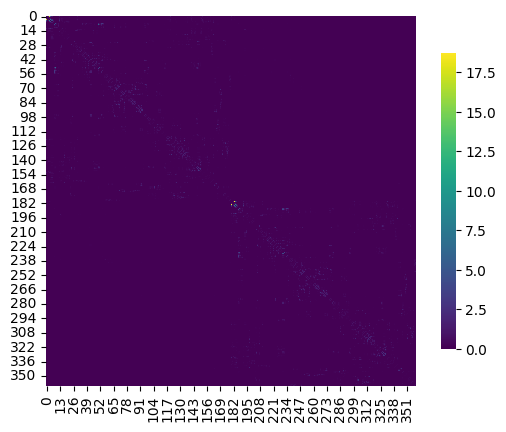

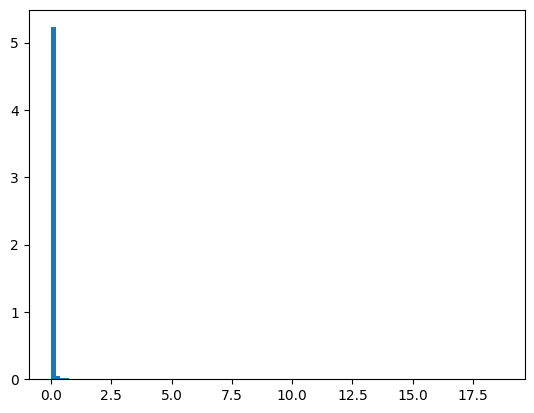

In [30]:
cm = cons_meanCM
sns.heatmap(cm, cmap='viridis', square=True, cbar_kws={"shrink": .8})
plt.figure()
plt.hist(cm.flatten(), bins=100, density=True)
#plt.ylim(0, 10)

## GM fitting

In [32]:
# define which CM to use

cm = cons_meanCM # CM_clean # cm_f # cm_f_top10
cm_name = 'cons_mean_sCM' # 'ind_sCM_cleaned' # 'ind_fCM'

In [33]:
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
n_components = 10

# Use the cleaned connectivity matrix
print(f"Computing gradients on cleaned matrix of shape: {CM_clean.shape}")
gm = GradientMaps(n_components=n_components, kernel='normalized_angle')
gm.fit(cm)

# Check if gradients have valid values
print(f"Gradient matrix shape: {gm.gradients_.shape}")
print(f"First gradient stats:")
print(f"Min: {np.nanmin(gm.gradients_[:, 0])}")
print(f"Max: {np.nanmax(gm.gradients_[:, 0])}")
print(f"NaN count: {np.sum(np.isnan(gm.gradients_[:, 0]))}")
print(f"Inf count: {np.sum(np.isinf(gm.gradients_[:, 0]))}")

Computing gradients on cleaned matrix of shape: (354, 354)
Gradient matrix shape: (360, 10)
First gradient stats:
Min: -0.03894397550046416
Max: 0.04895483095201194
NaN count: 0
Inf count: 0


In [34]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )

# Map gradients back to full parcel space, accounting for removed parcels
gm_= gm.gradients_.T 
grad = [None] * n_components

for i, g in enumerate(gm_): 
    if cm_name == 'ind_sCM_cleaned':
        full_gradient = np.full(len(parcels_mask), np.nan) # Create full gradient array with NaNs for removed parcels
        full_gradient[parcels_mask] = g  # Fill in valid parcels with gradient values
    else:
        full_gradient = g
    # Map to surface vertices
    grad[i] = map_to_labels(full_gradient, labeling_glasser, mask=mask_glasser, fill=np.nan)

print(f"Surface mapping completed for {n_components} gradients")
print(f"Surface map shape for each gradient: {grad[0].shape}")
print(f"First gradient surface map - Min: {np.nanmin(grad[0])}, Max: {np.nanmax(grad[0])}")
print(f"First gradient surface map - Valid values: {np.sum(np.isfinite(grad[0]))}")

Surface mapping completed for 10 gradients
Surface map shape for each gradient: (20484,)
First gradient surface map - Min: -0.03894397550046416, Max: 0.04895483095201194
First gradient surface map - Valid values: 18742


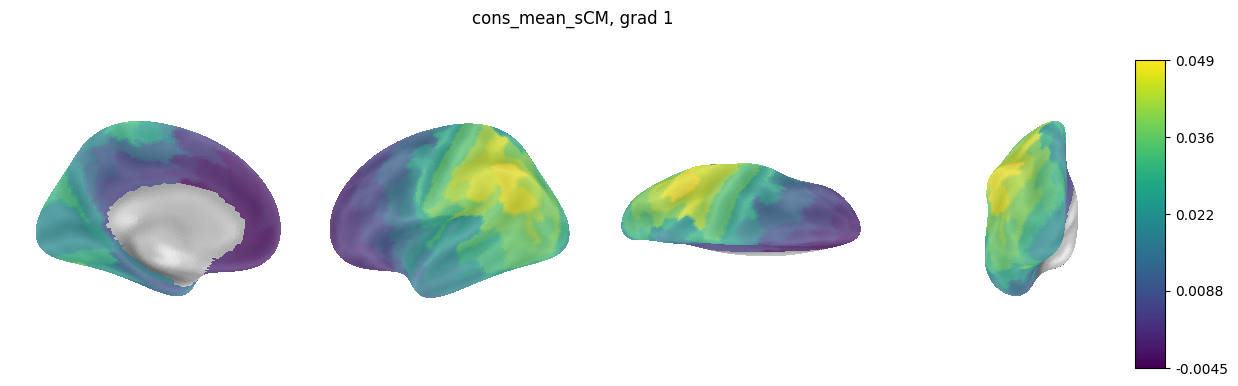

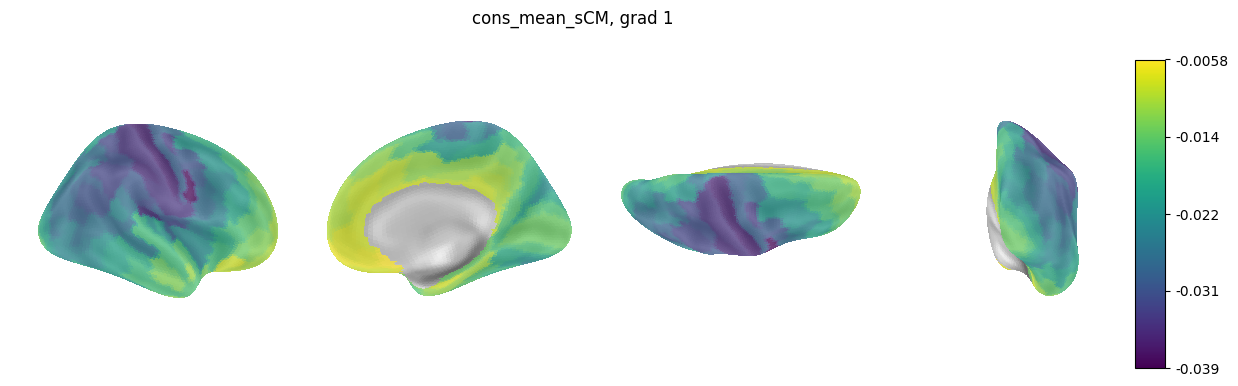

In [36]:
n_grad = 1 - 1
surf_map = grad[n_grad] # 0 is the first gradient, 1 is the second, etc.

from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt 
fsaverage = fetch_surf_fsaverage('fsaverage5') 
views = ['medial','lateral','dorsal','posterior']
cmap = 'viridis'


for i, hemi in enumerate(['L','R']):
    map = np.split(surf_map,2)[i]
    surf_mesh = fsaverage.infl_right if hemi =='R' else fsaverage.infl_left
    bg_map = fsaverage.sulc_right if hemi =='R' else fsaverage.sulc_left

    figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
    for i,view in enumerate(views):
        colbar = True if view == 'posterior' else False
        nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, # infl_right # pial_right
                view= view,cmap=cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
                bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
    figure.subplots_adjust(wspace=0.01)
    figure.suptitle(f'{cm_name}, grad {n_grad+1}', y=0.75)

In [ ]:
hemi = 'L' # 'R'
i_hemi = 0 
for n_grad in range(0,10):
    surf_map = grad[n_grad]
    map = np.split(surf_map,2)[i_hemi] 
    surf_mesh = fsaverage.infl_right if hemi =='R' else fsaverage.infl_left
    bg_map = fsaverage.sulc_right if hemi =='R' else fsaverage.sulc_left

    figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
    for i,view in enumerate(views):
        colbar = True if view == 'posterior' else False
        nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, # infl_right # pial_right
                view= view,cmap=cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
                bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
    figure.subplots_adjust(wspace=0.01)
    figure.suptitle(f'{cm_name}, grad {n_grad+1}', y=0.75)

In [123]:
avg_gradients.shape

(10, 354)

In [140]:
# is there on gradient that differs between hemispheres?
# should be the gradient where average gradien loadings per hemisphere is max differ

avg_gradients = np.array(gm_)
parcel_midpoint = avg_gradients.shape[1] // 2
#avg_gradients = np.nanmean(gradients, axis=1)  # Average across subjects
avg_gradients_L = avg_gradients[:, : parcel_midpoint]  # Left hemisphere
avg_gradients_R = avg_gradients[:,parcel_midpoint :]  # Right hemisphere
diffs = np.abs(avg_gradients_L.mean(axis=1) - avg_gradients_R.mean(axis=1))
max_diff_grad = np.argmax(diffs)
print(f"Gradient with max difference between hemispheres: {max_diff_grad + 1}",
      f" (Difference: {diffs[max_diff_grad]:.4f})")

Gradient with max difference between hemispheres: 2  (Difference: 0.0935)
